In [14]:
import mdtraj as md
import numpy as np
import pickle
import matplotlib.pyplot as plt
from iMSM.data_classes.input_data_classes import iMSMInput, iMSMInputSingleSim
from iMSM.data_classes.config_data_class import iMSMConfig
from iMSM.main import run

In [5]:
IMSM_CHECKPOINT_PATH = "data/nup_sims/imsm/"
TRAJ_PATH = "data/nup_sims/output_from_0_nowat_0.96ns_per_frame.dcd"
TOP_PATH = "data/nup_sims/output_from_0_nowat.dms.pdb"

In [10]:
# A1-860 are the kap
# A863 - 1125 are the FG


# 1. Load the trajectory and topology
traj = md.load(TRAJ_PATH, top=TOP_PATH)

# 2. Select ALL alpha carbon atom indices in the entire topology
all_ca_indices = traj.topology.select("name CA")

# 3. Slice the list of indices by your alpha carbon/amino acid count
# Note: Python indexing starts at 0.
# [:860] grabs indices 0 through 859 (your 1st through 860th alpha carbons)
kap_ca_indices = all_ca_indices[:860]

# [862:] grabs index 862 to the end (your 863rd alpha carbon onwards)
fg_ca_indices = all_ca_indices[862:]

# 4. Extract the coordinates for those specific slices
kap_xyz_mdtraj = traj.xyz[:, kap_ca_indices, :]
fg_xyz_mdtraj = traj.xyz[:, fg_ca_indices, :]

# 5. Transpose to your requested shape: (N_alphacarbons, 3, N_timepoints)
kap_coords = np.transpose(kap_xyz_mdtraj, (1, 2, 0))
fg_coords = np.transpose(fg_xyz_mdtraj, (1, 2, 0))


# construct the iMSMInputObject
full_coords = np.concatenate((kap_coords, fg_coords), axis=0)
components = np.array(["kap"] * kap_coords.shape[0] + [f"C{i}" for i in range(fg_coords.shape[0])])
trajectories = [iMSMInputSingleSim(trajectory=full_coords)]
input_data = iMSMInput(trajectories=trajectories, components=components, focal_component="C1")



print(f"Total Alpha Carbons found: {len(all_ca_indices)}")
print(f"Requested kap_coords shape: {kap_coords.shape}")
print(f"Requested fg_coords shape:  {fg_coords.shape}")

Total Alpha Carbons found: 1125
Requested kap_coords shape: (860, 3, 14981)
Requested fg_coords shape:  (263, 3, 14981)


In [23]:
    
config = iMSMConfig(checkpoints_path=f"{IMSM_CHECKPOINT_PATH}/")
config.window_size = 50 # number of frames to consider when generating interaction histograms. In the chingolin data, each frame is 1fs.
config.k_closest = 5 # number of closest neighbors to consider when generating interaction histograms.
config.max_surface_dist = 10.0 # maximum distance between two components for them to be considered interacting. In the chignolin data, distances are in Angstroms.
config.n_clusters = 20 # number of clusters to use for the clustering step
config.tm_prior = 0.01 # added to all entries counts matrix

# do all stages
config.start_stage = 1
config.end_stage = 5

input_data.focal_component = "C100"

# Run iMSM
run(input=input_data, config=config)

--- Running stage 1_categorization ---
--- Running stage 2_embedding ---
--- Running stage 3_clustering ---
--- Running stage 4_msm ---


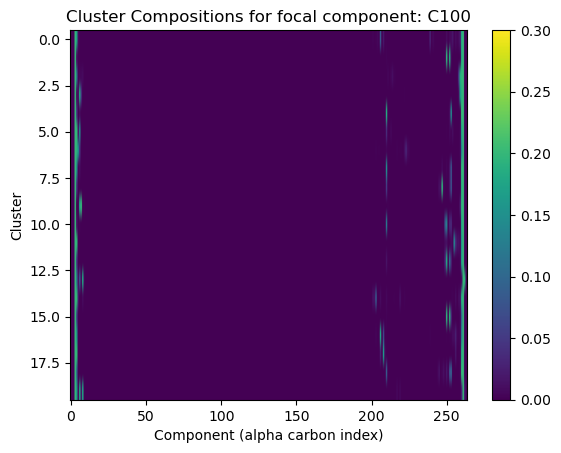

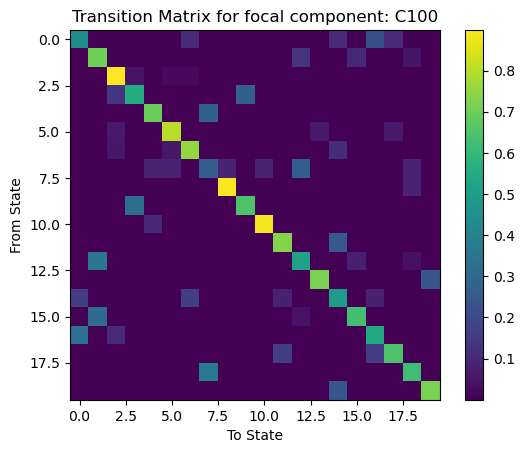

In [25]:
focal_component = "C100"
    
# visualize cluster compositions
cluster_compositons = np.zeros((20,264))
with open(f"{IMSM_CHECKPOINT_PATH}/3_clustering.pickle", "rb") as f:
    imsm_cluster = pickle.load(f)
for i in range(imsm_cluster.n_clusters):
    cluster_composition = imsm_cluster.clustering.cluster_centers_[i]
    cluster_compositons[i] = cluster_composition
plt.imshow(cluster_compositons, cmap='viridis', aspect='auto')
plt.colorbar()
plt.title("Cluster Compositions for focal component: " + focal_component)
plt.xlabel("Component (alpha carbon index)")
plt.ylabel("Cluster")
plt.clim(0, 0.3)
plt.show()

# visualize the msm transition matrix
with open(f"{IMSM_CHECKPOINT_PATH}/4_msm.pickle", "rb") as f:
    imsm_msm = pickle.load(f)
msm_matrix = imsm_msm.transition_matrix
plt.imshow(msm_matrix, cmap='viridis')
plt.colorbar()
plt.title("Transition Matrix for focal component: " + focal_component)
plt.xlabel("To State")
plt.ylabel("From State")
plt.show()